# **IMPORT LIBRARIES**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:

import seaborn as sns

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# **LOAD DATASET**

In [7]:
df = pd.read_csv("../data/Delivery_Logistics_reconstructed.csv")
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,expected_time_hours_recon,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,order_date_recon,order_ts_recon,delivery_ts_recon,expected_ts_recon,hour
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,no,delivered,5,1322.21,52.8,30,1.0,9.332489,1.001906,-43.467511,0,21-10-2024,21-10-2024 13.00,2024-10-21 22:19:56.959673890,23-10-2024 17.48,13
1,250.99,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,yes,delayed,2,595.53,8.0,35,1.1,4.129935,1.001906,-3.870065,0,02-01-2024,02-01-2024 12.00,2024-01-02 16:07:47.764281093,02-01-2024 20.00,12
2,250.99,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,yes,delayed,2,1608.49,26.4,45,1.0,7.427398,1.001906,-18.972602,0,31-05-2024,31-05-2024 11.00,2024-05-31 18:25:38.631406710,01-06-2024 13.24,11
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,no,delivered,3,469.01,48.0,30,1.1,3.997011,1.001906,-44.002989,0,03-01-2024,03-01-2024 17.00,2024-01-03 20:59:49.240153885,05-01-2024 17.00,17
4,250.99,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,no,delivered,4,1045.27,52.8,40,1.2,6.933351,1.001906,-45.866649,0,19-03-2024,19-03-2024 13.00,2024-03-19 19:56:00.063604276,21-03-2024 17.48,13


In [8]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir())


Current directory: d:\CHRISTSEM6\EY_INTERNSHIP\ETA-Delay-Prediction\notebooks

Files in current directory:
['01_eda.ipynb', '02_preprocessing.ipynb', '03_baseline_model.ipynb']


In [9]:

print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)

Dataset Loaded Successfully
Shape of dataset: (25000, 25)


# **SCHEMA & STRUCTURE**

In [10]:
print("Column Names:\n")

for col in df.columns:
    print(col)


Column Names:

delivery_id
delivery_partner
package_type
vehicle_type
delivery_mode
region
weather_condition
distance_km
package_weight_kg
delayed
delivery_status
delivery_rating
delivery_cost
expected_time_hours_recon
speed_kmph_recon
weather_mult_recon
delivery_time_hours_recon
partner_mult_recon
delay_hours_recon
delayed_flag_recon
order_date_recon
order_ts_recon
delivery_ts_recon
expected_ts_recon
hour


In [11]:
print("Dataset Schema Information:")
df.info()

Dataset Schema Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   delivery_id                25000 non-null  float64
 1   delivery_partner           25000 non-null  object 
 2   package_type               25000 non-null  object 
 3   vehicle_type               25000 non-null  object 
 4   delivery_mode              25000 non-null  object 
 5   region                     25000 non-null  object 
 6   weather_condition          25000 non-null  object 
 7   distance_km                25000 non-null  float64
 8   package_weight_kg          25000 non-null  float64
 9   delayed                    25000 non-null  object 
 10  delivery_status            25000 non-null  object 
 11  delivery_rating            25000 non-null  int64  
 12  delivery_cost              25000 non-null  float64
 13  expected_time_hour

In [12]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,expected_time_hours_recon,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,order_date_recon,order_ts_recon,delivery_ts_recon,expected_ts_recon,hour
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,no,delivered,5,1322.21,52.8,30,1.0,9.332489,1.001906,-43.467511,0,21-10-2024,21-10-2024 13.00,2024-10-21 22:19:56.959673890,23-10-2024 17.48,13
1,250.99,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,yes,delayed,2,595.53,8.0,35,1.1,4.129935,1.001906,-3.870065,0,02-01-2024,02-01-2024 12.00,2024-01-02 16:07:47.764281093,02-01-2024 20.00,12
2,250.99,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,yes,delayed,2,1608.49,26.4,45,1.0,7.427398,1.001906,-18.972602,0,31-05-2024,31-05-2024 11.00,2024-05-31 18:25:38.631406710,01-06-2024 13.24,11
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,no,delivered,3,469.01,48.0,30,1.1,3.997011,1.001906,-44.002989,0,03-01-2024,03-01-2024 17.00,2024-01-03 20:59:49.240153885,05-01-2024 17.00,17
4,250.99,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,no,delivered,4,1045.27,52.8,40,1.2,6.933351,1.001906,-45.866649,0,19-03-2024,19-03-2024 13.00,2024-03-19 19:56:00.063604276,21-03-2024 17.48,13


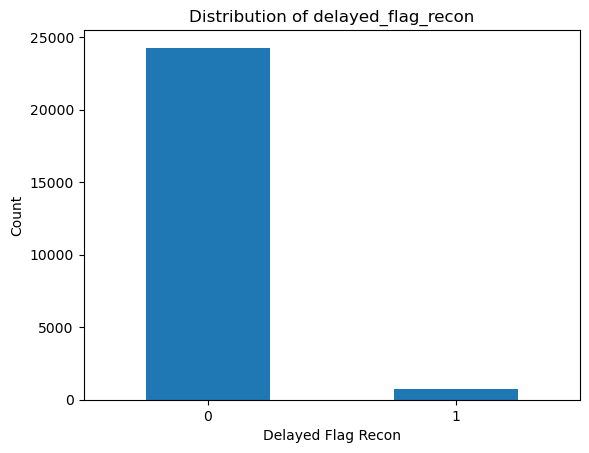

In [13]:
import matplotlib.pyplot as plt

# Count values
counts = df['delayed_flag_recon'].value_counts()

# Plot
plt.figure()
counts.plot(kind='bar')

plt.xlabel('Delayed Flag Recon')
plt.ylabel('Count')
plt.title('Distribution of delayed_flag_recon')
plt.xticks(rotation=0)
plt.show()

In [14]:
df['delayed_flag_recon'].value_counts()

0    24265
1      735
Name: delayed_flag_recon, dtype: int64

# **MISSING VALUES ANALYSIS**

In [12]:
# Calculate missing values count
missing_count = df.isnull().sum()

In [13]:
# Calculate missing percentage
missing_percentage = (missing_count / len(df)) * 100

In [14]:
# Missing values summary
missing_summary = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_percentage
}).sort_values(by='Missing_Percentage', ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
delivery_id,0,0.0
expected_time_hours_recon,0,0.0
expected_ts_recon,0,0.0
delivery_ts_recon,0,0.0
order_ts_recon,0,0.0
order_date_recon,0,0.0
delayed_flag_recon,0,0.0
delay_hours_recon,0,0.0
partner_mult_recon,0,0.0
delivery_time_hours_recon,0,0.0


# **Duplicate Records Check**

In [15]:
# Total number of duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [16]:
# Percentage of duplicates
duplicate_percentage = (duplicate_count / len(df)) * 100
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")


Percentage of duplicate rows: 0.00%


# **NUMERICAL SUMMARY**

In [17]:
numeric_summary = df.describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
delivery_id,25000.0,12500.500000,7212.732314,250.990000,6250.750000,12500.500000,18750.250000,24750.010000
distance_km,25000.0,150.390436,86.409745,3.600000,75.900000,151.000000,224.900000,297.100000
package_weight_kg,25000.0,25.145898,14.368663,0.670000,12.680000,25.145000,37.660000,49.520000
delivery_rating,25000.0,3.666000,1.149964,1.000000,3.000000,4.000000,5.000000,5.000000
delivery_cost,25000.0,864.944579,435.712593,95.667400,490.800000,867.535000,1237.910000,1632.720600
expected_time_hours_recon,25000.0,33.053344,17.592341,8.000000,24.000000,26.400000,48.000000,52.800000
speed_kmph_recon,25000.0,39.976200,6.465300,30.000000,35.000000,40.000000,45.000000,50.000000
weather_mult_recon,25000.0,1.100310,0.064465,1.000000,1.050000,1.100000,1.150000,1.200000
delivery_time_hours_recon,25000.0,5.360406,2.631007,0.640518,3.180450,5.227587,7.307020,13.682192
partner_mult_recon,25000.0,0.999994,0.003666,0.993437,0.998812,1.000945,1.002187,1.005584


# **NUMERICAL DISTRIBUTIONS**

In [18]:
# Select only numeric columns from dataset
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numeric Columns:", numeric_columns)

Numeric Columns: Index(['delivery_id', 'distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost',
       'expected_time_hours_recon', 'speed_kmph_recon', 'weather_mult_recon', 'delivery_time_hours_recon',
       'partner_mult_recon', 'delay_hours_recon', 'delayed_flag_recon', 'hour'],
      dtype='object')


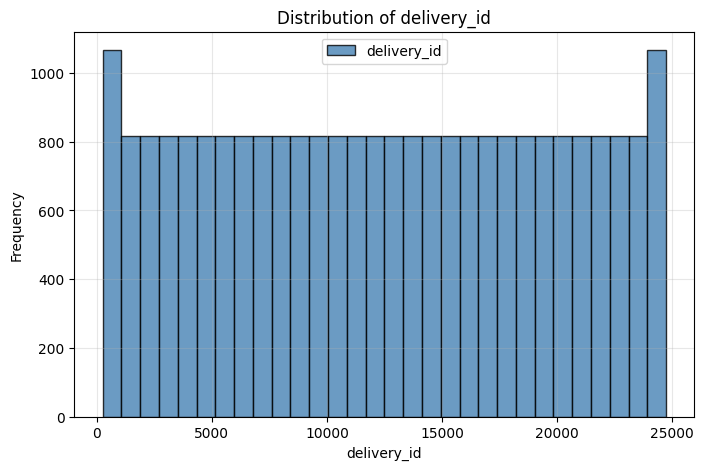

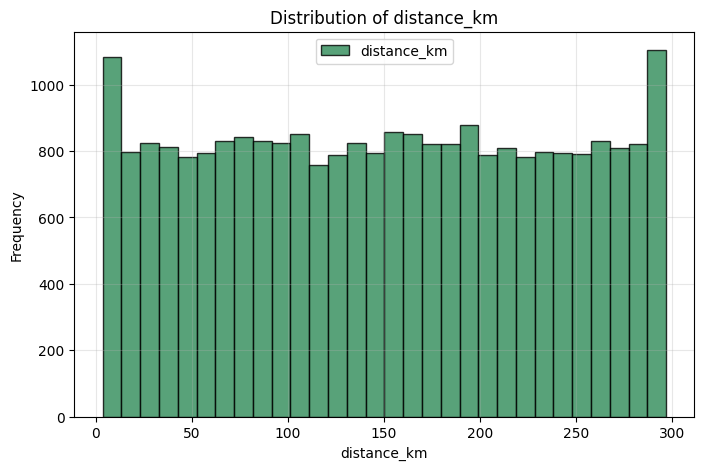

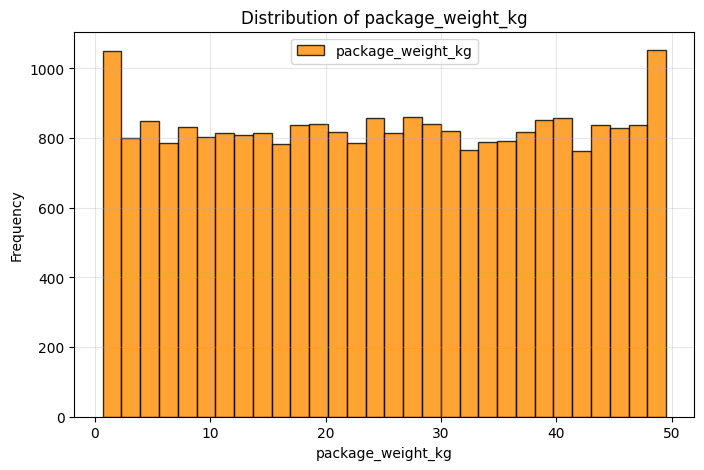

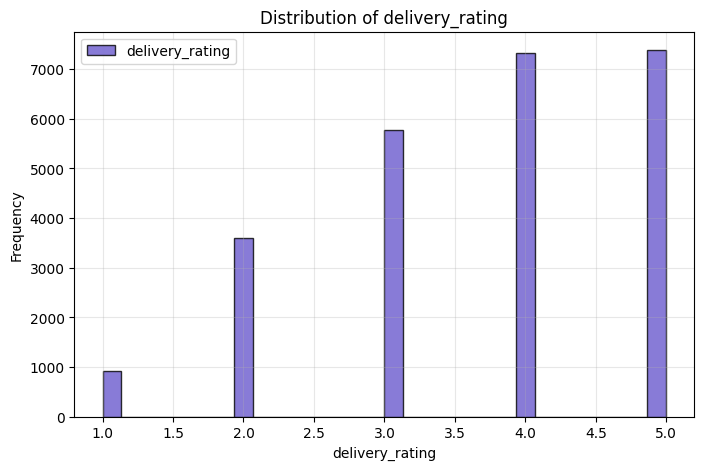

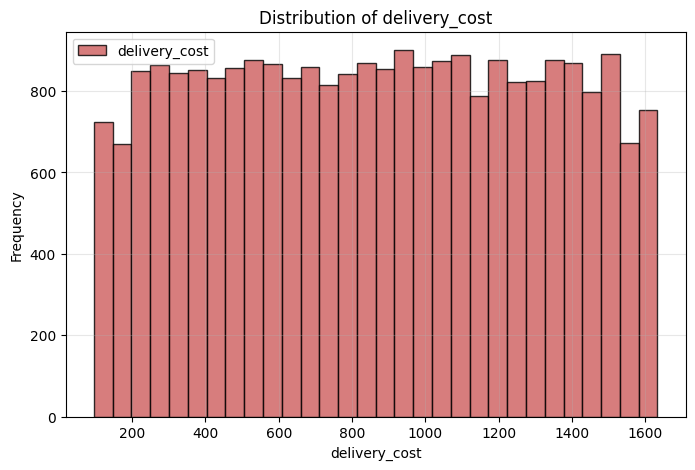

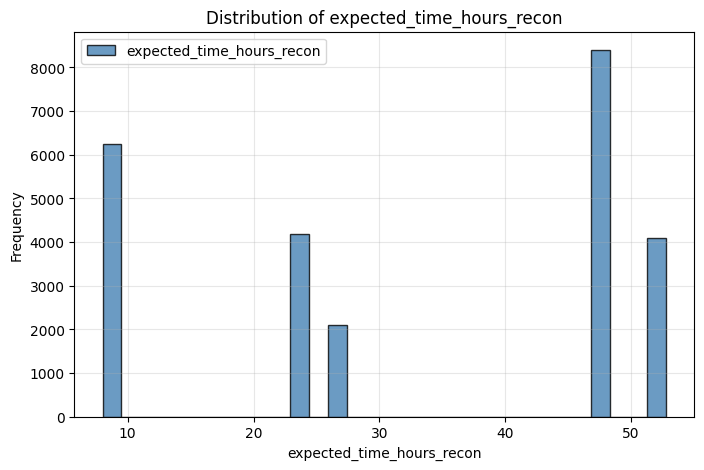

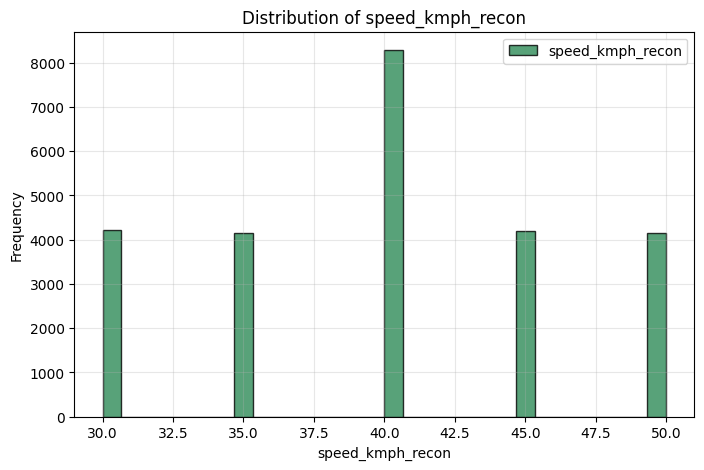

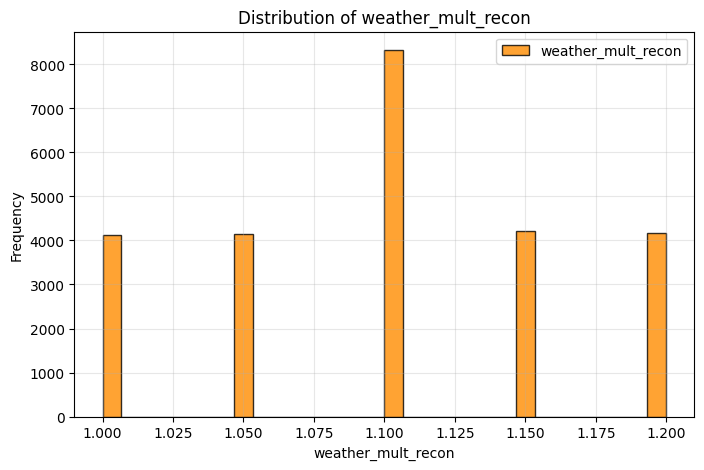

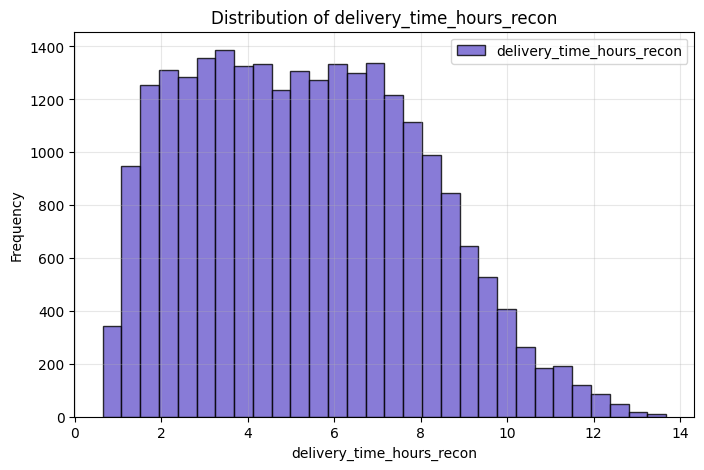

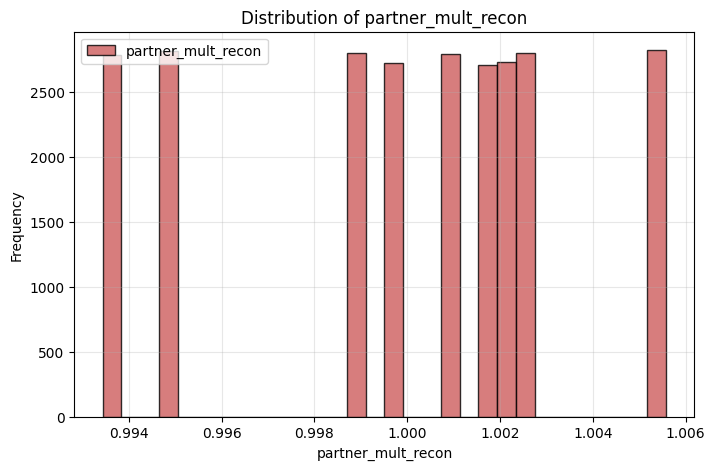

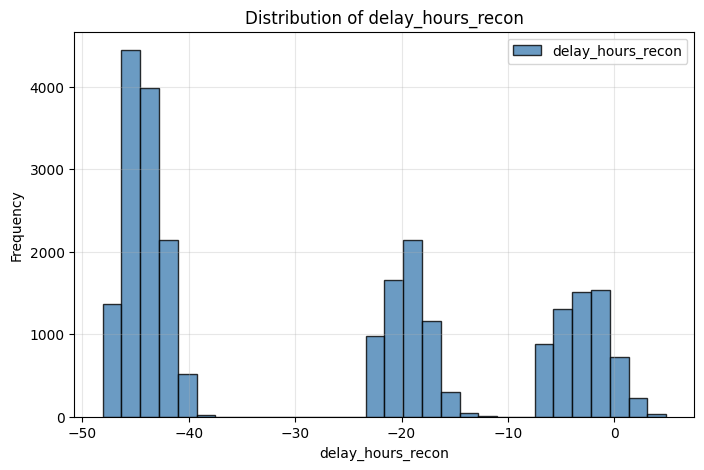

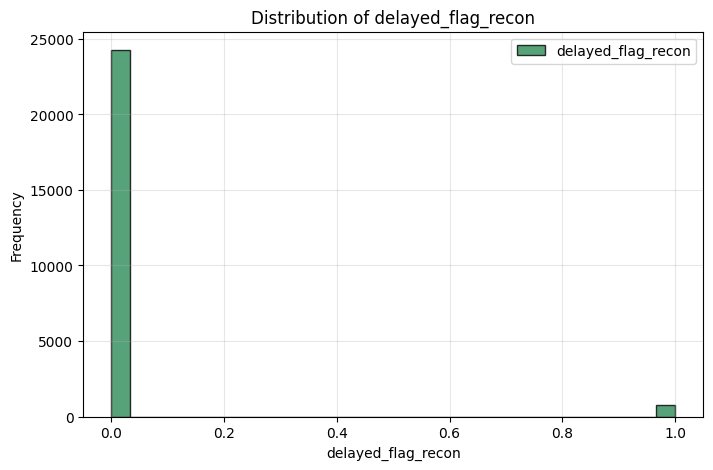

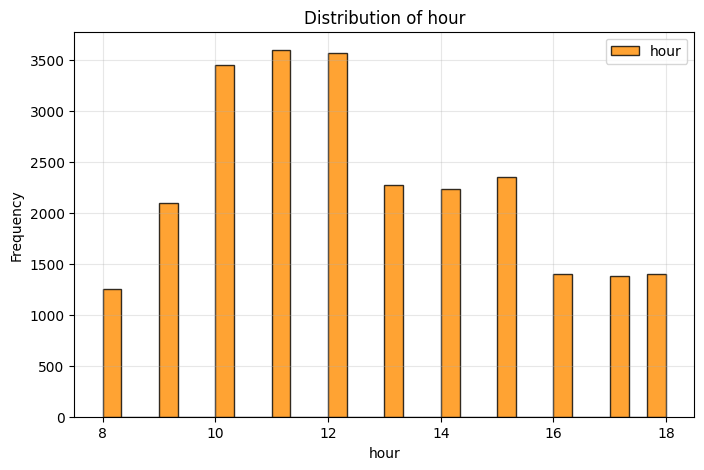

In [19]:
colors = ['steelblue', 'seagreen', 'darkorange', 'slateblue', 'indianred']

for i, col in enumerate(numeric_columns):
    plt.figure(figsize=(8, 5))
    plt.hist(
        df[col],
        bins=30,
        color=colors[i % len(colors)],
        edgecolor='black',
        alpha=0.8,
        label=col
    )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# **CATEGORICAL SUMMARY**

In [20]:
#Percentage of total records belonging to each category.
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(normalize=True).head(10) * 100)


Column: delivery_partner
Unique values: 9
delivery_partner
xpressbees          11.304
fedex               11.272
dhl                 11.208
ekart               11.204
blue dart           11.192
delhivery           11.144
shadowfax           10.944
ecom express        10.888
amazon logistics    10.844
Name: proportion, dtype: float64

Column: package_type
Unique values: 9
package_type
fragile items       11.392
pharmacy            11.240
documents           11.220
automobile parts    11.180
electronics         11.168
clothing            11.068
furniture           10.984
cosmetics           10.976
groceries           10.772
Name: proportion, dtype: float64

Column: vehicle_type
Unique values: 6
vehicle_type
ev bike    16.872
van        16.748
scooter    16.696
bike       16.640
truck      16.580
ev van     16.464
Name: proportion, dtype: float64

Column: delivery_mode
Unique values: 4
delivery_mode
two day     25.208
same day    25.116
express     24.932
standard    24.744
Name: proport

# **CATEGORICAL DISTRIBUTIONS**

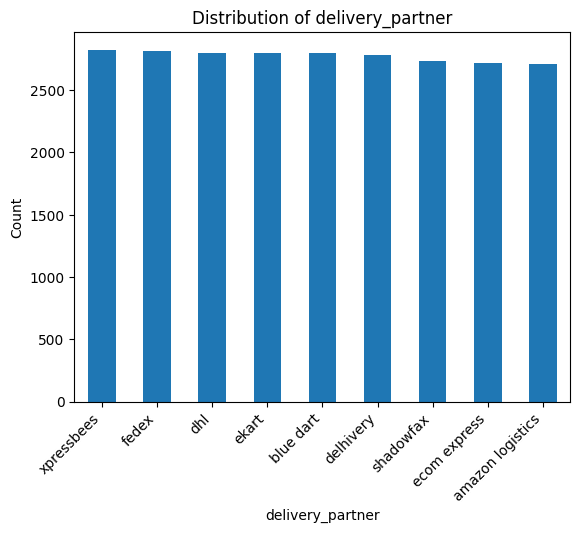

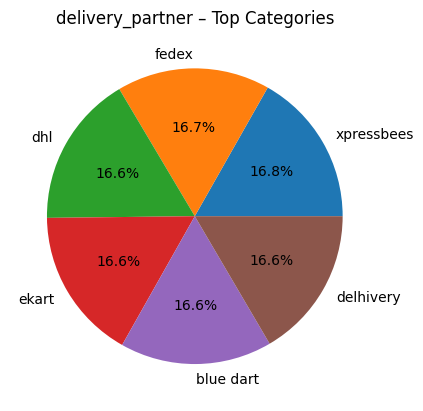

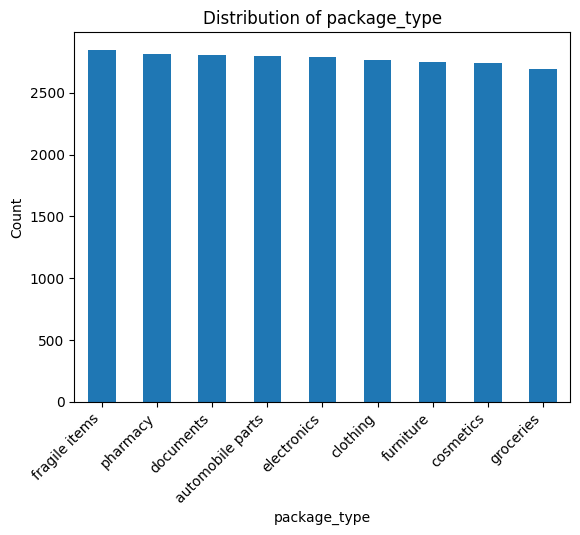

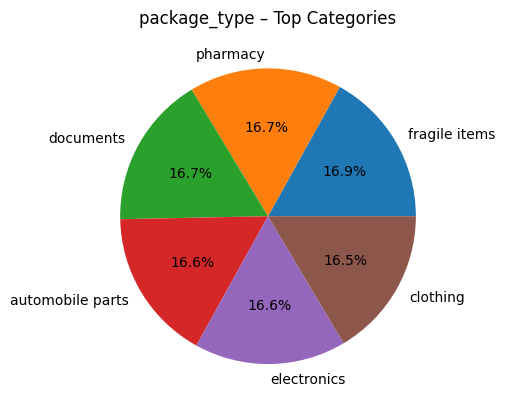

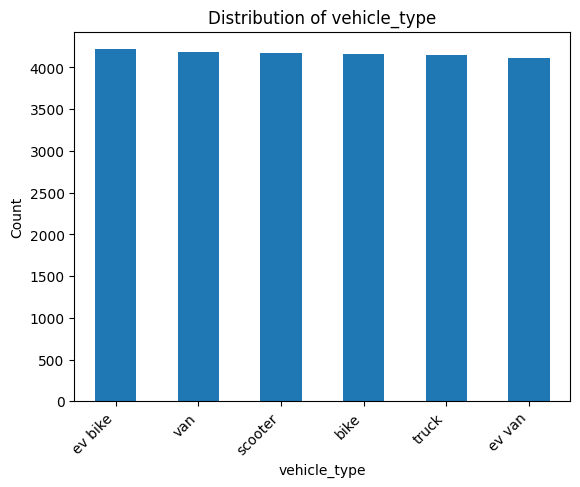

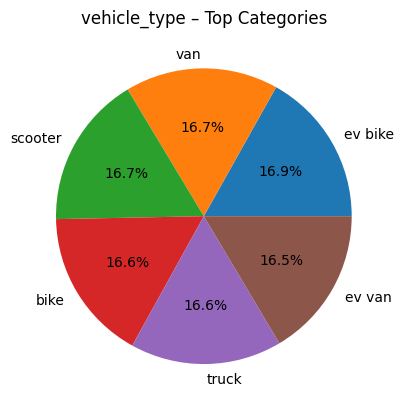

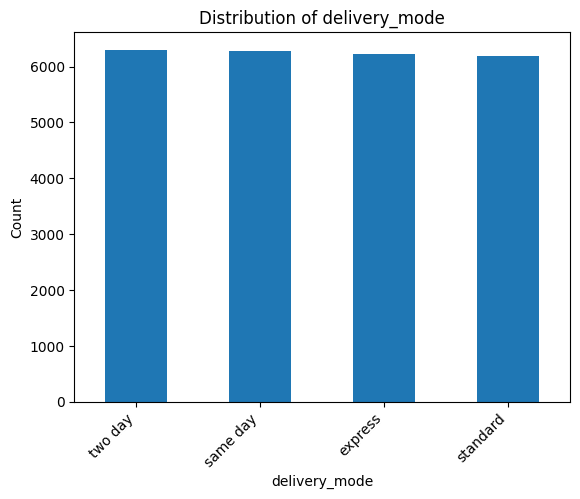

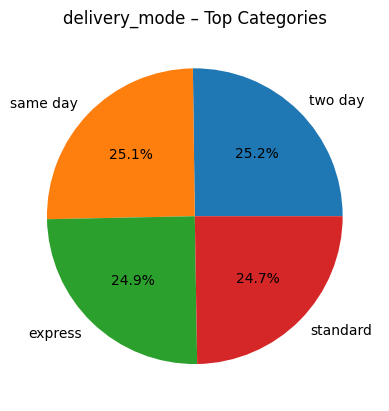

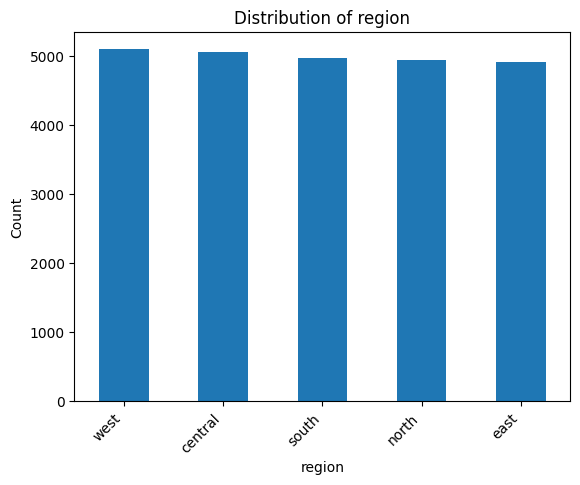

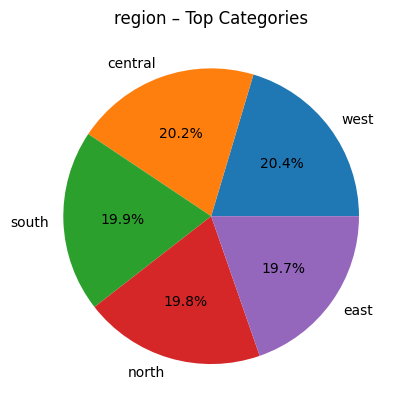

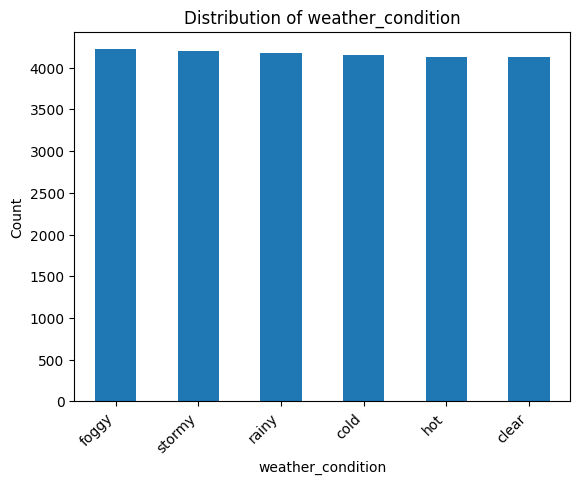

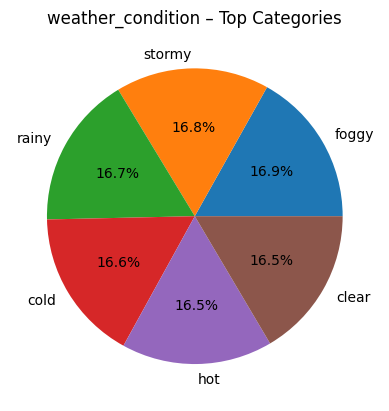

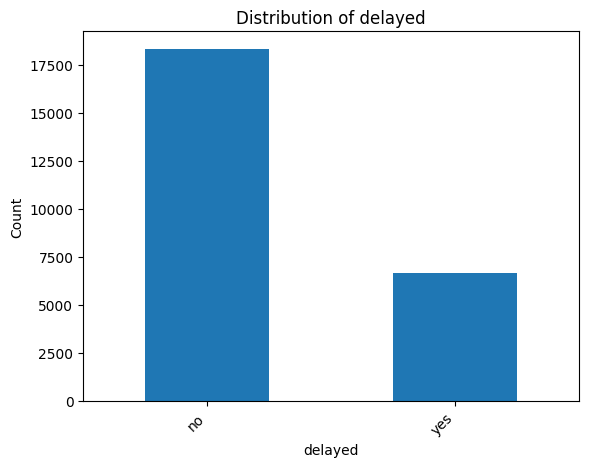

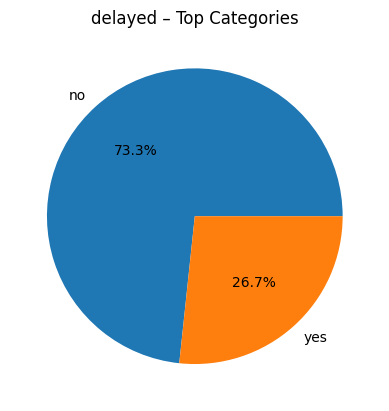

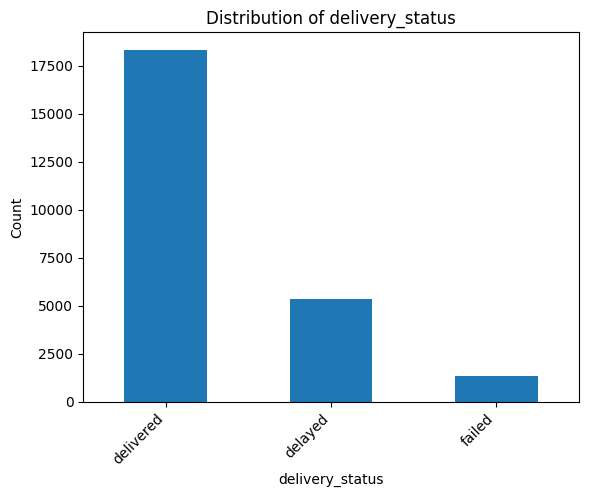

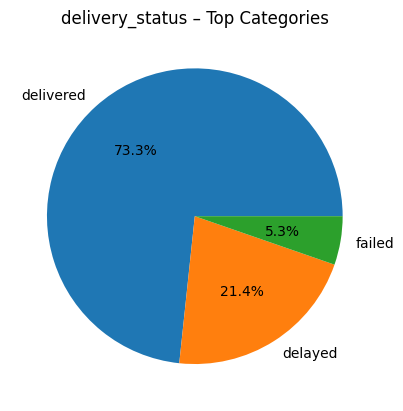

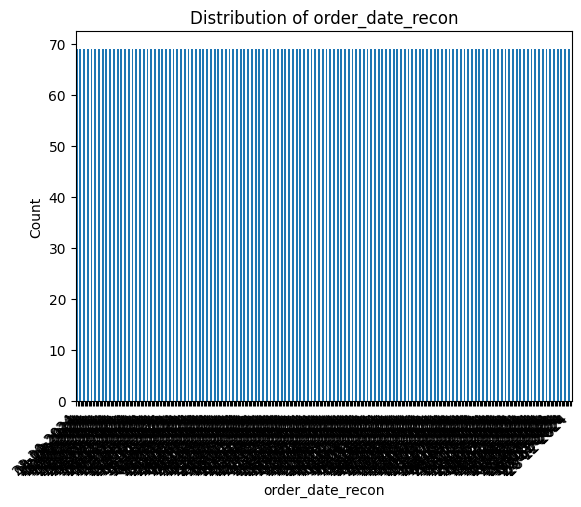

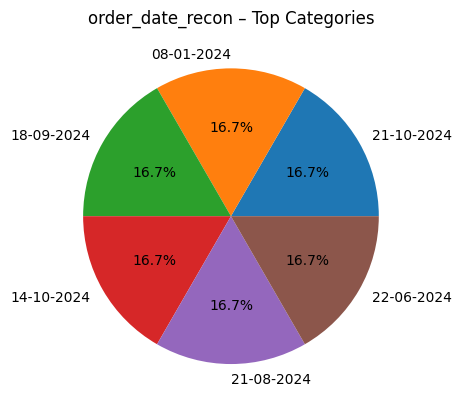

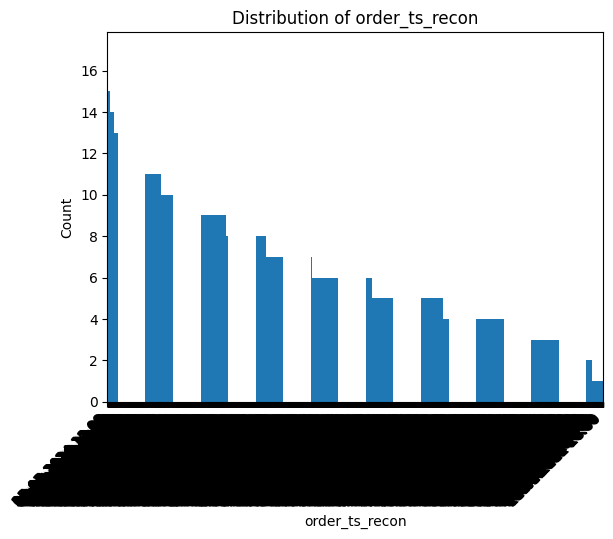

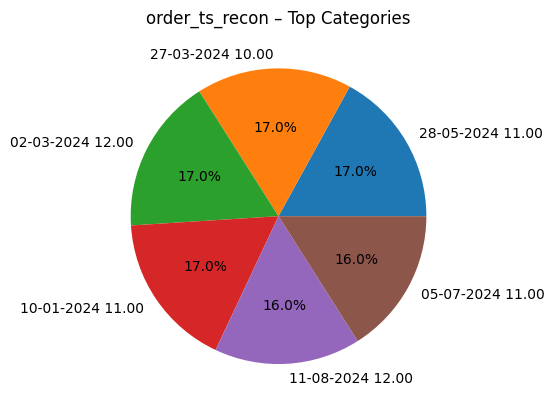

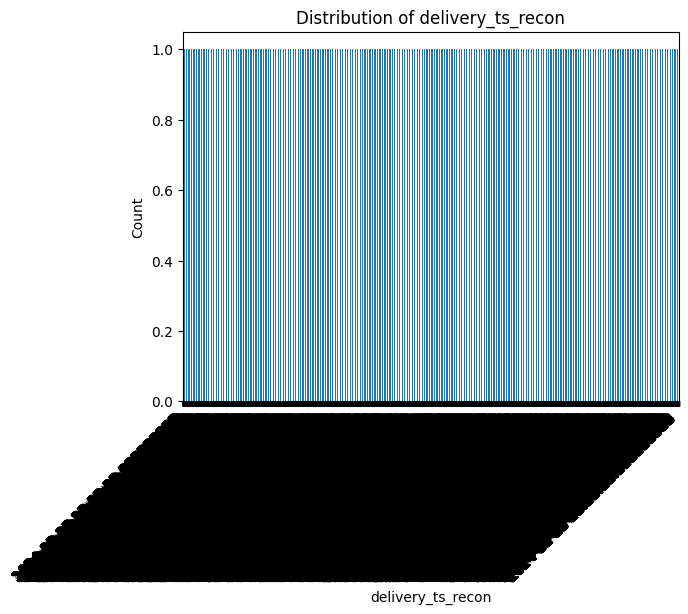

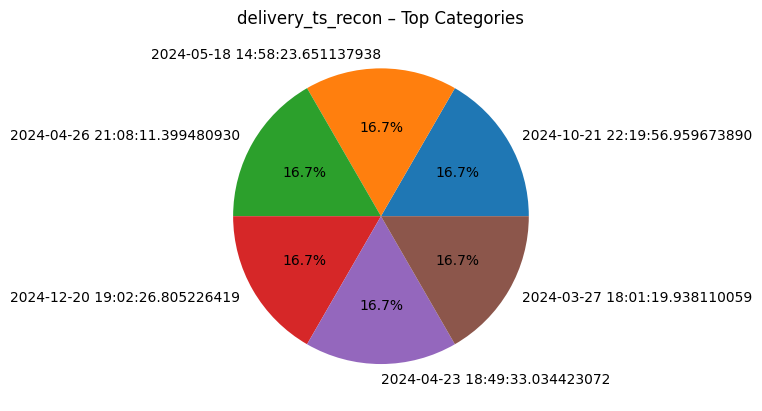

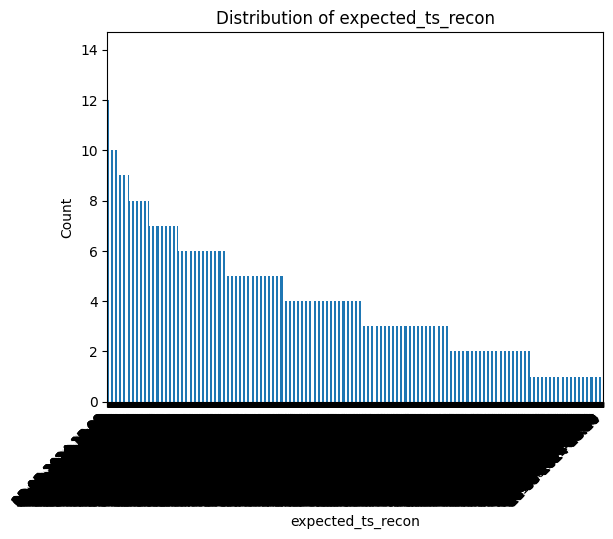

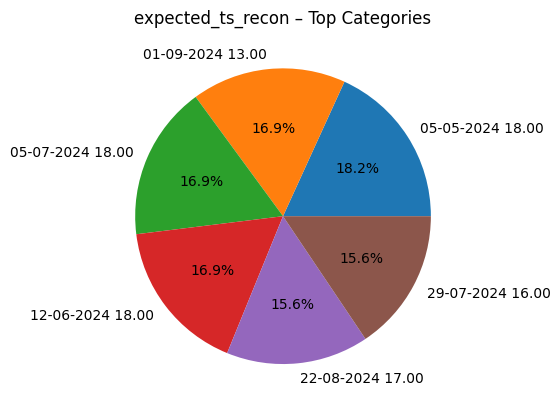

In [23]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    value_counts = df[col].value_counts()

    # BAR CHART

    plt.figure()
    value_counts.plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.show()


    # PIE CHART
    plt.figure()
    value_counts.head(6).plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'{col} – Top Categories')
    plt.ylabel('')
    plt.show()


# **WEATHER vs DELIVERY STATUS**

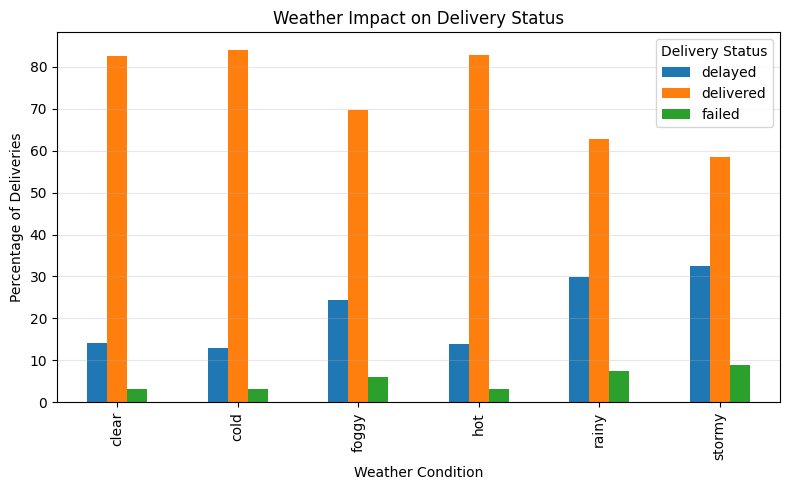

In [24]:
weather_delay = pd.crosstab(
    df['weather_condition'],
    df['delivery_status'],
    normalize='index'
) * 100

weather_delay.plot(kind='bar', figsize=(8, 5))
plt.title('Weather Impact on Delivery Status')
plt.xlabel('Weather Condition')
plt.ylabel('Percentage of Deliveries')
plt.legend(title='Delivery Status')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **REGION-WISE DELAY ANALYSIS**

region
central    27.252964
west       26.947988
south      26.783203
north      26.571024
east       25.797926
Name: delayed, dtype: float64


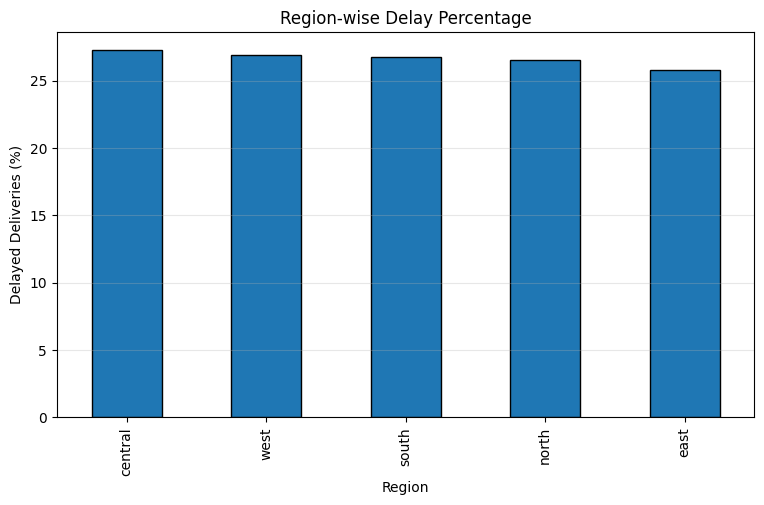

In [25]:
region_delay_pct = (
    df.groupby("region")["delayed"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

print(region_delay_pct)


region_delay_pct.plot(kind="bar", figsize=(9,5), edgecolor="black")

plt.title("Region-wise Delay Percentage")
plt.xlabel("Region")
plt.ylabel("Delayed Deliveries (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()


# **VEHICLE TYPE vs DELAY**

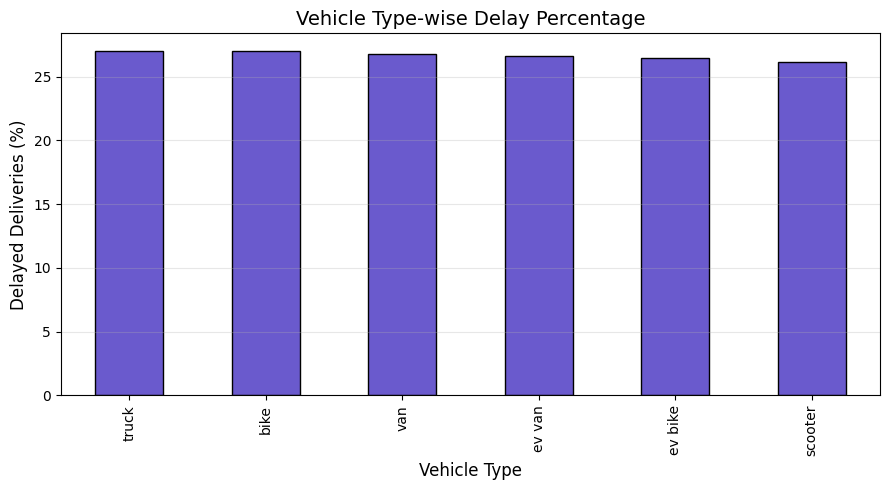

In [26]:
vehicle_delay = (
    df.groupby("vehicle_type")["delayed"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
vehicle_delay.plot(kind="bar", color="slateblue", edgecolor="black")
plt.title("Vehicle Type-wise Delay Percentage", fontsize=14)
plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Delayed Deliveries (%)", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# **DISTANCE vs DELAY**

<Figure size 700x500 with 0 Axes>

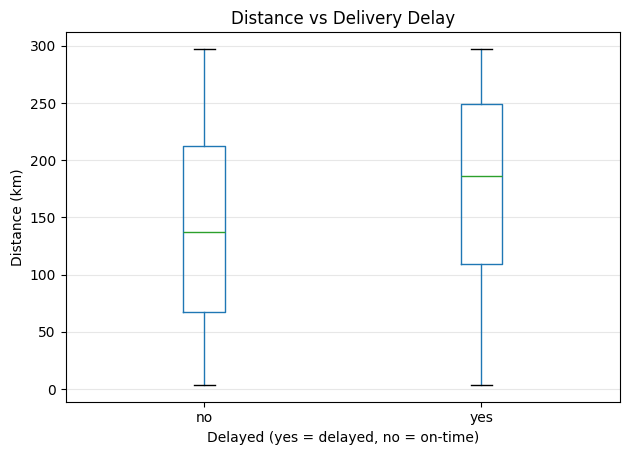

In [27]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column='distance_km',
    by='delayed',
    grid=False
)

plt.title('Distance vs Delivery Delay')
plt.suptitle('')
plt.xlabel('Delayed (yes = delayed, no = on-time)')
plt.ylabel('Distance (km)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# **COLUMN-WISE OUTLIER DETECTION**

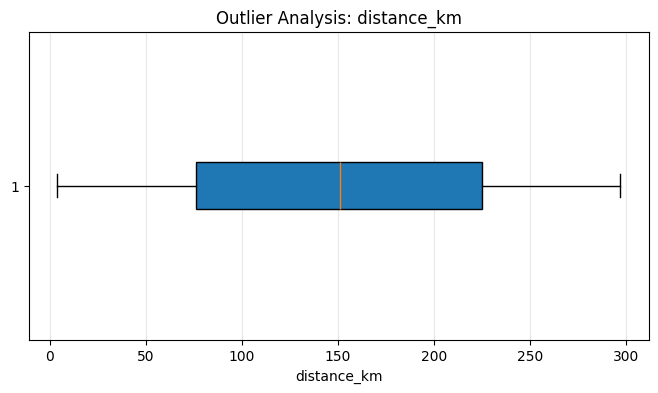

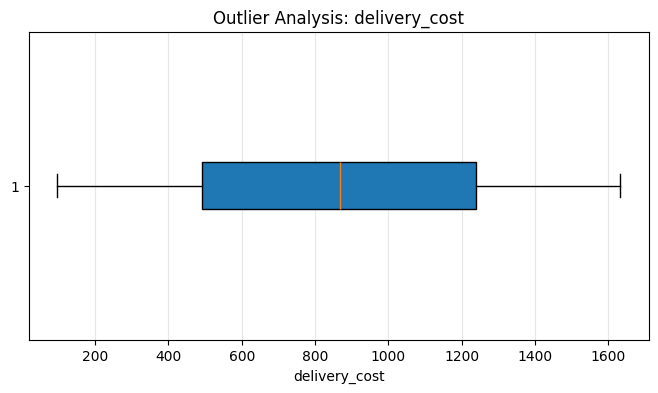

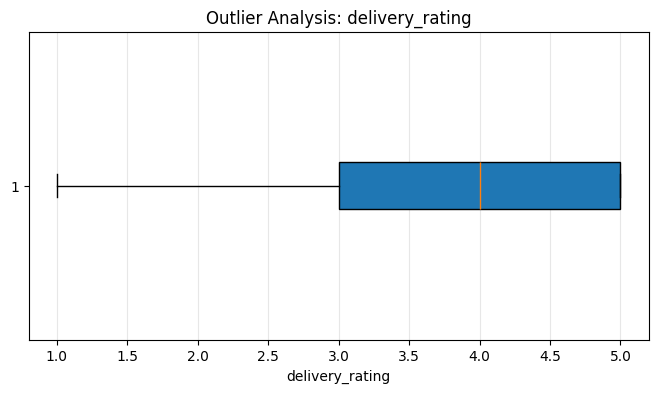

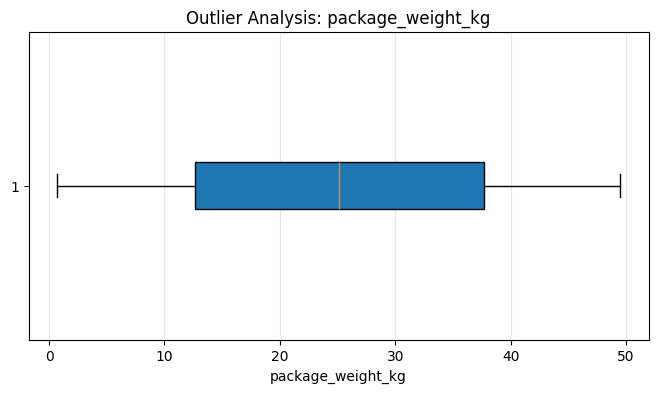

In [28]:
outlier_columns = [
    "distance_km",
    "delivery_cost",
    "delivery_rating",
    "package_weight_kg"
]

for col in outlier_columns:
    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[col],
        vert=False,
        patch_artist=True
    )

    plt.title(f"Outlier Analysis: {col}")
    plt.xlabel(col)
    plt.grid(axis="x", alpha=0.3)
    plt.show()


# **CORRELATION HEATMAP**

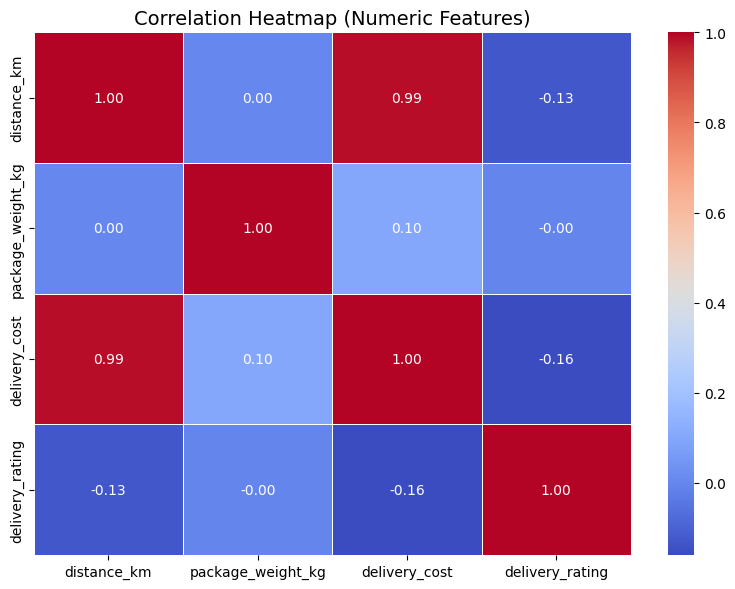

In [29]:
heatmap_columns = [
    'distance_km',
    'package_weight_kg',
    'delivery_cost',
    'delivery_rating'
]

corr_matrix = df[heatmap_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Numeric Features)", fontsize=14)
plt.tight_layout()
plt.show()


# **NUMERIC vs TARGET**

<Figure size 700x500 with 0 Axes>

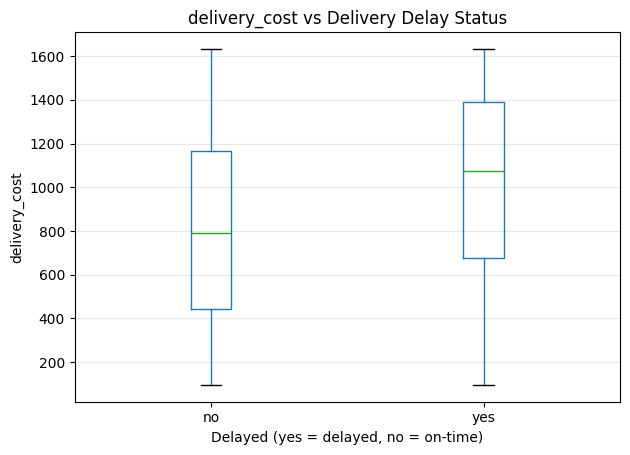

<Figure size 700x500 with 0 Axes>

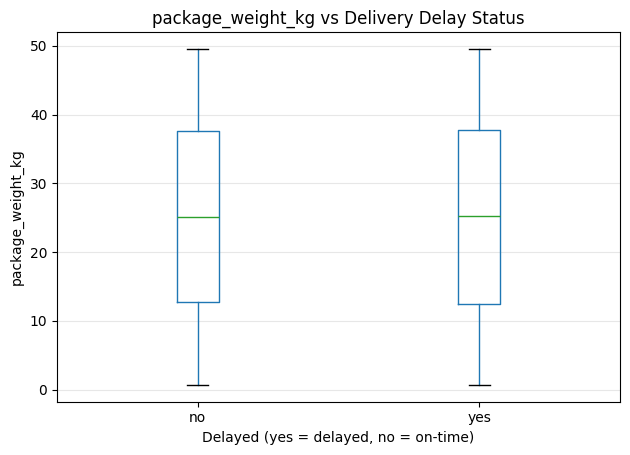

<Figure size 700x500 with 0 Axes>

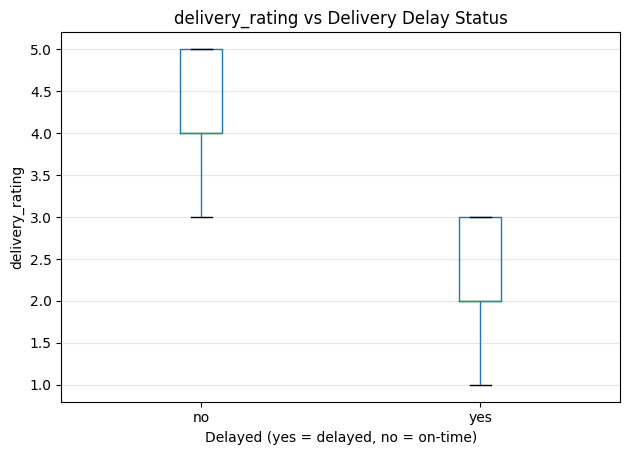

In [30]:
numeric_vs_target = [
    'delivery_cost',
    'package_weight_kg',
    'delivery_rating'
]

for col in numeric_vs_target:
    plt.figure(figsize=(7, 5))

    df.boxplot(
        column=col,
        by='delayed',   # existing column
        grid=False
    )

    plt.title(f'{col} vs Delivery Delay Status')
    plt.suptitle('')
    plt.xlabel('Delayed (yes = delayed, no = on-time)')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


Interpertation

The dataset is clean, balanced across categorical features, and free from missing values or duplicates. Numerical features show meaningful distributions, and business relationships such as weather impact and distance-related delays are observable. The primary challenge identified is class imbalance in delayed deliveries, which will require handling during model training.

Challenges: 

1) Datetime columns need conversion

2) Class imbalance exists

3) Some weak predictors

4) High correlation features